In [1]:
import torch
import numpy as np
import requests
import json
from pathlib import Path
from typing import Optional
from display_retrieval import display_retrieval_results


# ─── Lazy imports (model berat, di-load saat dibutuhkan) ─────────────────────
_sentence_model = None
_clip_model     = None
_clip_processor = None

# ─── Konfigurasi ──────────────────────────────────────────────────────────────
QDRANT_HOST        = "http://76.13.195.1"
QDRANT_PORT        = 6333
VECTOR_SIZE        = 1024
TEXT_COLLECTION    = "semantic_chunks"
TEXT_MODEL_NAME    = "microsoft/harrier-oss-v1-0.6b"
DEVICE             = "cuda" if torch.cuda.is_available() else "cpu"

In [2]:
def get_sentence_model():
    """Lazy-load SentenceTransformer untuk text embedding."""
    global _sentence_model
    if _sentence_model is None:
        from sentence_transformers import SentenceTransformer
        print(f"⏳ Loading text model: {TEXT_MODEL_NAME}")
        _sentence_model = SentenceTransformer(TEXT_MODEL_NAME)
        print("✅ Text model loaded")
    return _sentence_model

def embed_text_for_text_vdb(query: str) -> list:
    """
    Embed query menggunakan SentenceTransformer untuk mencari di Text VDB.
    Prefix 'query: ' diperlukan oleh model harrier.
    """
    model = get_sentence_model()
    prefixed = f"query: {query.strip()}"
    vector = model.encode(
        [prefixed],
        normalize_embeddings=True,
        convert_to_numpy=True,
    )[0]
    return vector.tolist()

def search_qdrant(collection= TEXT_COLLECTION, vector= VECTOR_SIZE, top_k= 5,
                   filter_payload: Optional[dict] = None) -> list:
    """
    Generik search ke Qdrant via REST API.
    Returns list of hit dicts: {id, score, payload}
    """
    url = f"{QDRANT_HOST}:{QDRANT_PORT}/collections/{collection}/points/search"
    payload = {
        "vector":       vector,
        "limit":        top_k,
        "with_payload": True,
    }
    if filter_payload:
        payload["filter"] = filter_payload

    try:
        response = requests.post(url, json=payload, timeout=30)
        response.raise_for_status()
        return response.json().get("result", [])
    except requests.exceptions.ConnectionError:
        raise ConnectionError(f"❌ Tidak bisa terhubung ke Qdrant: {url}")
    except requests.exceptions.HTTPError as e:
        raise RuntimeError(f"❌ HTTP Error dari Qdrant: {e}")
    except Exception as e:
        raise RuntimeError(f"❌ Error saat query Qdrant: {e}")

def retrieve_text(query: str, top_k: int = 5) -> list:
    """
    Retrieve chunk teks relevan dari VDB 'semantic_chunks'.

    Returns:
        list of dict: [{score, text, metadata}]
    """
    if not query.strip():
        raise ValueError("Query tidak boleh kosong.")

    vector  = embed_text_for_text_vdb(query)
    hits    = search_qdrant(TEXT_COLLECTION, vector, top_k)

    results = []
    for hit in hits:
        payload = hit.get("payload", {})
        results.append({
            "score":    hit.get("score", 0.0),
            "text":     payload.get("text", payload.get("page_content", "N/A")),
            "metadata": payload.get("metadata", {}),
            "source_file": payload.get("source_file", "N/A"),
        })
    return results

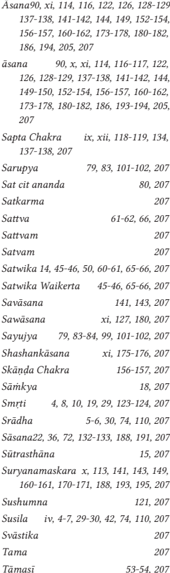

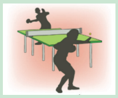

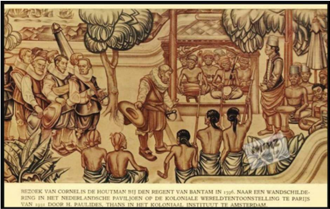

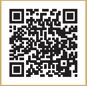

In [7]:
retriever = [retrieve_text(query="Sabar dan tawakal", top_k=5)]
display_retrieval_results(retriever)
